In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# 1. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [6]:
import pandas as pd

# 1. Carregando as bases com os nomes atualizados
df_reservas = pd.read_csv('reservas.concat.corrigido.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.concat.csv', sep=';')
df_unidades = pd.read_csv('unidades.concat.csv', sep=';')

# Bases extras carregadas para as próximas etapas do painel
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';')
df_clientes = pd.read_csv('clientes.concat.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.concat.csv', sep=';')

# 2. Executando o cruzamento da Pergunta 3
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

print("Bases carregadas e cruzamento realizado com sucesso!")

Bases carregadas e cruzamento realizado com sucesso!


In [7]:
# 1. Cruzamento para calcular o faturamento real por reserva
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']



In [8]:
# 2. Medindo a discrepância estatística: Agrupamento com métricas resumo
resumo_estatistico = df_merged.groupby('nome_unidade')['faturamento_reserva'].agg(['count', 'mean', 'median', 'std', 'sum']).reset_index()
resumo_estatistico.columns = ['Unidade', 'Qtd Reservas', 'Faturamento Médio', 'Mediana', 'Desvio Padrão', 'Faturamento Total']
resumo_estatistico = resumo_estatistico.sort_values(by='Faturamento Total', ascending=False)

# Formatando a tabela resumo para apresentação executiva
tabela_discrepancia = resumo_estatistico.copy()
tabela_discrepancia['Faturamento Médio'] = tabela_discrepancia['Faturamento Médio'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_discrepancia['Faturamento Total'] = tabela_discrepancia['Faturamento Total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(tabela_discrepancia)



,Unidade,Qtd Reservas,Faturamento Médio,Mediana,Desvio Padrão,Faturamento Total
9,NaraHoteis Paraty,372,"R$ 2.486,05",1740.0,2002.300087,"R$ 924.810,00"
4,NaraHoteis Friburgo,368,"R$ 2.445,65",1740.0,1991.679589,"R$ 900.000,00"
6,NaraHoteis Mangaratiba,380,"R$ 2.360,71",1740.0,1943.796647,"R$ 897.070,00"
12,NaraHoteis Teresópolis,350,"R$ 2.507,60",1820.0,2052.359592,"R$ 877.660,00"
8,NaraHoteis Nova Iguaçu Park,346,"R$ 2.489,97",1820.0,2088.599073,"R$ 861.530,00"
11,NaraHoteis Santa Teresa,391,"R$ 2.179,85",1740.0,1760.034084,"R$ 852.320,00"
1,NaraHoteis Barra da Tijuca,356,"R$ 2.341,43",1680.0,2001.110093,"R$ 833.550,00"
10,NaraHoteis Petrópolis,340,"R$ 2.425,26",1740.0,2026.871891,"R$ 824.590,00"
5,NaraHoteis Ipanema,375,"R$ 2.181,79",1680.0,1784.464975,"R$ 818.170,00"
0,NaraHoteis Angra dos Reis,339,"R$ 2.347,20",1740.0,1975.214495,"R$ 795.700,00"


C:\Users\Robert\AppData\Local\Temp\ipykernel_6120\1496417274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='nome_unidade', y='faturamento_reserva', palette='Set3')


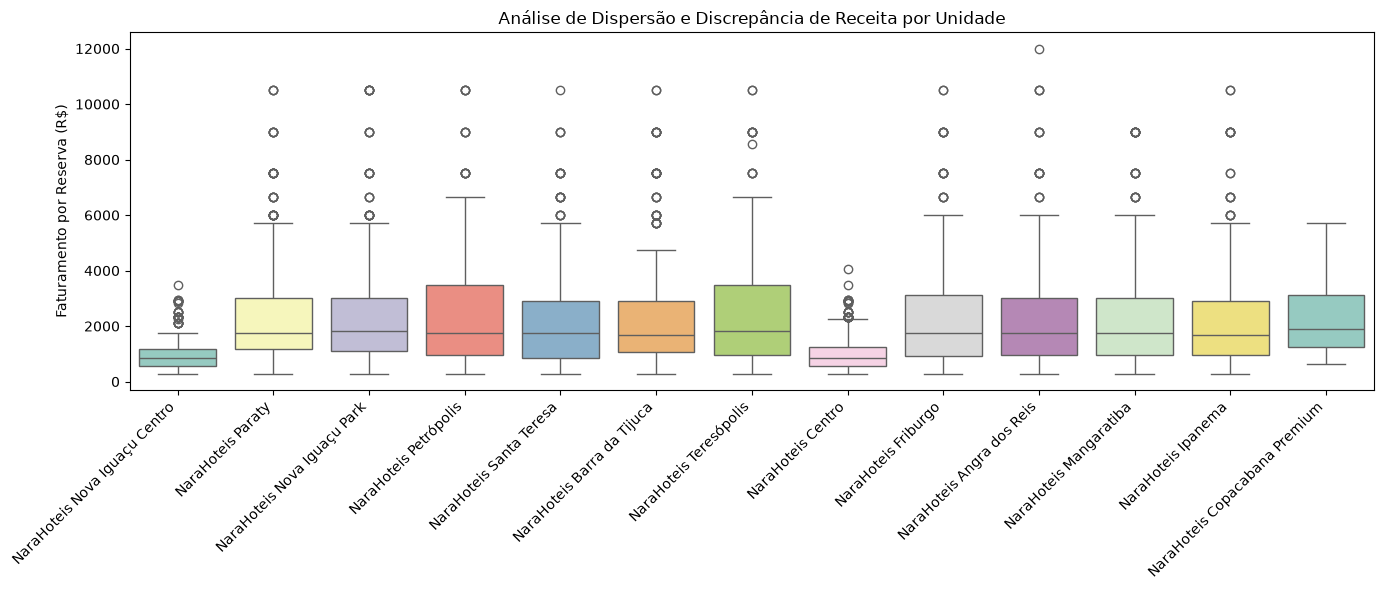

In [9]:

# 3. Visualização Gráfica: Boxplot de Faturamento por Unidade
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_merged, x='nome_unidade', y='faturamento_reserva', palette='Set3')
plt.title('Análise de Dispersão e Discrepância de Receita por Unidade')
plt.xlabel('')
plt.ylabel('Faturamento por Reserva (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

PERGUNTA

Existem unidades com performance de receita discrepante em relação às demais? Como você identificaria, mediria e comprovaria isso?

RESPOSTA 3 

A Discrepância de Esforço (Unidades Centro): As filiais NaraHoteis Centro e Nova Iguaçu Centro são os maiores pontos fora da curva negativos. A estatística comprova isso mostrando uma contradição: elas lideram o volume de reservas da rede (478 e 424 reservas, respectivamente), mas possuem o pior Faturamento Médio (cerca de R$ 980 a R$ 1.021). Isso indica um esforço operacional altíssimo (mais check-ins, mais limpeza, mais desgaste) para um retorno financeiro muito baixo.

A Discrepância de Volume (Copacabana Premium): Esta unidade aparece na lanterna do Faturamento Total (R$ 298.500), mas a estatística prova que o problema dela não é a desvalorização do serviço. O Faturamento Médio é excelente (R$ 2.296) e a Mediana é a segunda maior da rede (R$ 1.900). A discrepância aqui é puramente a falta de volume (apenas 130 reservas). Porem é uma unidade recem inalgurada.

O Padrão de Sucesso (Ecossistema de Lazer): O bloco superior, liderado por Paraty, Friburgo e Mangaratiba, define a meta ideal da rede. Elas sustentam um volume saudável (em torno de 350 a 380 reservas) alinhado a Faturamentos Médios robustos (acima de R$ 2.300). Elas provam que o modelo de negócios voltado para turismo e lazer é altamente rentável.



In [10]:
# 1. Calculando o Faturamento Total da Rede e a Participação Percentual por Unidade
faturamento_total_rede = resumo_estatistico['Faturamento Total'].sum()

resumo_estatistico['Participação Rede (%)'] = (resumo_estatistico['Faturamento Total'] / faturamento_total_rede) * 100

# 2. Calculando a Curva ABC Acumulada
resumo_estatistico = resumo_estatistico.sort_values(by='Faturamento Total', ascending=False)
resumo_estatistico['Participação Acumulada (%)'] = resumo_estatistico['Participação Rede (%)'].cumsum()

# 3. Formatando para visualização executiva
tabela_abc = resumo_estatistico[['Unidade', 'Faturamento Total', 'Participação Rede (%)', 'Participação Acumulada (%)']].copy()
tabela_abc['Faturamento Total'] = tabela_abc['Faturamento Total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabela_abc['Participação Rede (%)'] = tabela_abc['Participação Rede (%)'].apply(lambda x: f"{x:.2f}%")
tabela_abc['Participação Acumulada (%)'] = tabela_abc['Participação Acumulada (%)'].apply(lambda x: f"{x:.2f}%")

display(tabela_abc)

,Unidade,Faturamento Total,Participação Rede (%),Participação Acumulada (%)
9,NaraHoteis Paraty,"R$ 924.810,00",9.45%,9.45%
4,NaraHoteis Friburgo,"R$ 900.000,00",9.19%,18.64%
6,NaraHoteis Mangaratiba,"R$ 897.070,00",9.16%,27.81%
12,NaraHoteis Teresópolis,"R$ 877.660,00",8.97%,36.77%
8,NaraHoteis Nova Iguaçu Park,"R$ 861.530,00",8.80%,45.58%
11,NaraHoteis Santa Teresa,"R$ 852.320,00",8.71%,54.28%
1,NaraHoteis Barra da Tijuca,"R$ 833.550,00",8.52%,62.80%
10,NaraHoteis Petrópolis,"R$ 824.590,00",8.42%,71.22%
5,NaraHoteis Ipanema,"R$ 818.170,00",8.36%,79.58%
0,NaraHoteis Angra dos Reis,"R$ 795.700,00",8.13%,87.71%
